In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем данные

Проанализировав частично некоторые строки таблицы:
>Нужно автоматизировать анализ атрибутов

In [ ]:

# Смотрим атрибут region
region = pd.read_excel('data_orphans_127_v20241218.xlsx', usecols = ['region'], nrows=5000)
print(region)

                   region
0       Республика Адыгея
1       Республика Адыгея
2       Республика Адыгея
3       Республика Адыгея
4       Республика Адыгея
...                   ...
4995  Воронежская область
4996  Воронежская область
4997  Воронежская область
4998  Воронежская область
4999  Воронежская область

[5000 rows x 1 columns]


In [ ]:
unique_regions = region['region'].unique()
print(unique_regions)

<StringArray>
[                       'Республика Адыгея',
                         'Республика Алтай',
                  'Республика Башкортостан',
                       'Республика Бурятия',
                      'Республика Дагестан',
                     'Республика Ингушетия',
          'Кабардино-Балкарская Республика',
                      'Республика Калмыкия',
          'Карачаево-Черкесская Республика',
                       'Республика Карелия',
                          'Республика Коми',
                      'Республика Марий Эл',
                      'Республика Мордовия',
                 'Республика Саха (Якутия)',
      'Республика Северная Осетия — Алания',
                     'Республика Татарстан',
                          'Республика Тыва',
                    'Удмуртская Республика',
                       'Республика Хакасия',
                     'Чеченская Республика',
                     'Чувашская Республика',
                           'Алтайский кра

# Цели
**Масштаб проблемы**
1.Количество детей-сирот и дети, оставшиеся без попечения родителей (динамика по годам)

2.Дети, нуждающиеся в устройстве в семьи (динамика по годам)

3.Приток детей за год (Выявлены и учтены на конец отчетного года)

4.Численность детей, родители которых лишены или ограничены в родительских правах

**Ресурсы**
1.Численность специалистов госсектора, занимающихся решением проблемы
2.Количество организаций, занимающихся выявлением и устройством сирот

**Результаты**
1.Дети, устроенные в семьи за год
2.Отмены решений о передаче в семью (возврат детей, ранее устроенных в семьи, в органы опеки)

**Взаимосвязи**
1.Семьи, готовые усыновить детей VS дети на предварительной опеке — точечная диаграмма (scatter) по регионам за выбранный год (укажите какой)
Количество усыновлённых детей по годам и регионам — таблица/сводная таблица (строки — регионы, столбцы — годы, значения — количество).

In [6]:
# Загружаем только необходимые колонки
df = pd.read_excel('data_orphans_127_v20241218.xlsx', 
                   usecols=['year', 'region', 'indicator_category', 'dimension', 
                            'main_level', 'indicator', 'indicator_value'])

# Быстро проверим размер
print(df.shape)
print(df.head(2))

(864205, 7)
   year             region                                 indicator_category  \
0  2014  Республика Адыгея  1. Учет и устройство детей, оставшихся без поп...   
1  2014  Республика Адыгея  1. Учет и устройство детей, оставшихся без поп...   

  dimension                                         main_level  \
0     всего  детей выявлено и учтено, всего, на конец отчет...   
1     всего  детей выявлено и учтено, всего, на конец отчет...   

                                           indicator  indicator_value  
0  детей, оставшихся неустроенными к началу отчет...                1  
1       детей, выявленных и учтенных за отчетный год              172  


Уникальные значения по каждому атрибуту

In [ ]:
# 1. indicator_category
print("=== indicator_category ===")
print(df['indicator_category'].unique())
print(f"Всего: {df['indicator_category'].nunique()}\n")



=== indicator_category ===
<StringArray>
[                      '1. Учет и устройство детей, оставшихся без попечения родителей',
 '2. Движение численности детей, находящихся на воспитании в семьях, за предыдущий год',
                                                          '3. Устройство детей в семьи',
                           '4. Граждан, желающих принять ребенка на воспитание в семьи',
                                                                 '5. Зашита прав детей',
                                                     '6. Специалисты по охране детства']
Length: 6, dtype: str
Всего: 6



In [ ]:
# 2. dimension
print("=== dimension ===")
print(df['dimension'].unique())
print(f"Всего: {df['dimension'].nunique()}\n")


=== dimension ===
<StringArray>
[                                                                                                                                                            'всего',
                                                                                                                                     'Опекаемые (подопечные), всего',
                                                                                                                    'Опекаемые (подопечные) посторонними гражданами',
                                                'Опекаемые (подопечные) добровольно переданные родителями по заявлению о назначении их ребенку опекуна (попечителя)',
                                                                                                'Опекаемые (подопечные), на которых выплачиваются денежные средства',
                                                                                     'Опекаемые (подопечные), переданные под предварительн

In [ ]:

# 3. main_level
print("=== main_level ===")
print(df['main_level'].unique())
print(f"Всего: {df['main_level'].nunique()}\n")



=== main_level ===
<StringArray>
[                                                                                                                                                                                                                                   'детей выявлено и учтено, всего, на конец отчетного года',
                                                                                                                                                                                                                                               'детей, выявленных и учтенных за отчетный год',
                                                                                                                                                                                                                                                                                       'main',
                                                                                                          

In [ ]:
# 4. indicator (только первые 30, т.к. может быть много)
print("=== indicator (первые 30 уникальных) ===")
unique_ind = df['indicator'].unique()
print(unique_ind[:30])
print(f"Всего уникальных indicator: {len(unique_ind)}")

=== indicator (первые 30 уникальных) ===
<StringArray>
[                                                                                                          'детей, оставшихся неустроенными к началу отчетного года',
                                                                                                                      'детей, выявленных и учтенных за отчетный год',
                                                                                                                                                       'детей-сирот',
                                                                                                                                               'в возрасте до 7 лет',
                                                                                                                                                 'девочек (девушек)',
                                                                                                           'детей в

# Динамика сирот по годам 
dimension = 'всего' в контексте indicator_category = '1. Учет и устройство...' означает агрегированный показатель без разбивки по дополнительным признакам (пол, возраст, тип устройства).

Т.о. фильтр:

indicator_category = '1. Учет и устройство детей, оставшихся без попечения родителей'

dimension = 'всего'

indicator = 'детей выявлено и учтено, всего, на конец отчетного года'

In [ ]:
mask = (df['indicator_category'] == '1. Учет и устройство детей, оставшихся без попечения родителей') & \
        (df['dimension'] == 'всего') & (df['indicator'] == 'детей выявлено и учтено, всего, на конец отчетного года')

df_total = df[mask]
print(f'1) Количество детей-сирот и дети, оставшиеся без попечения родителей - колво строк: {len(df_total)}')
print(df_total[['year', 'region', 'indicator_value']].head())

1) Количество детей-сирот и дети, оставшиеся без попечения родителей - колво строк: 861
     year                   region  indicator_value
5    2014        Республика Адыгея              173
46   2014         Республика Алтай              217
87   2014  Республика Башкортостан             1843
128  2014       Республика Бурятия              889
169  2014      Республика Дагестан              739


In [ ]:
"""Взяли наш датафрейм с фильтрацией, сделали суммы для каждого года-группы"""
russia_by_year = df_total.groupby('year')['indicator_value'].sum().reset_index()
#DONE: группа-год | значение сирот, ему соответствующих в сумме
print(russia_by_year)

    year  indicator_value
0   2013            73331
1   2014           130324
2   2015           120222
3   2016           117432
4   2017           101062
5   2018            98212
6   2019            95280
7   2020            88420
8   2021            95090
9   2022            92148
10  2023            85398


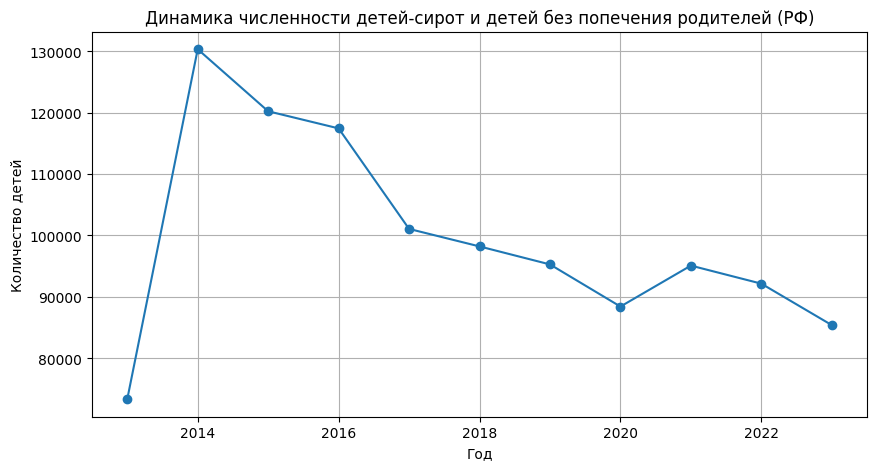

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
"""Горизонт - год, вертикаль - число сирот"""
plt.plot(russia_by_year['year'], russia_by_year['indicator_value'], marker='o', linestyle='-')
plt.title('Динамика численности детей-сирот и детей без попечения родителей (РФ)')
plt.xlabel('Год')
plt.ylabel('Количество детей')
plt.grid(True)
plt.show()

<u>DONE</u>:
- [x] 1.Количество детей-сирот и дети, оставшиеся без попечения родителей (динамика по годам)
___

# Динамика детей, нуждающихся в устройстве в семьи по годам

In [ ]:

mask = (df['indicator_category'] == '1. Учет и устройство детей, оставшихся без попечения родителей') & \
        (df['dimension'] == 'всего') & (df['indicator'] == 'численность детей, оставшихся неустроенными на конец отчетного года')

df_total_2 = df[mask]

russia_by_year_need_fam = df_total_2.groupby('year')['indicator_value'].sum().reset_index()

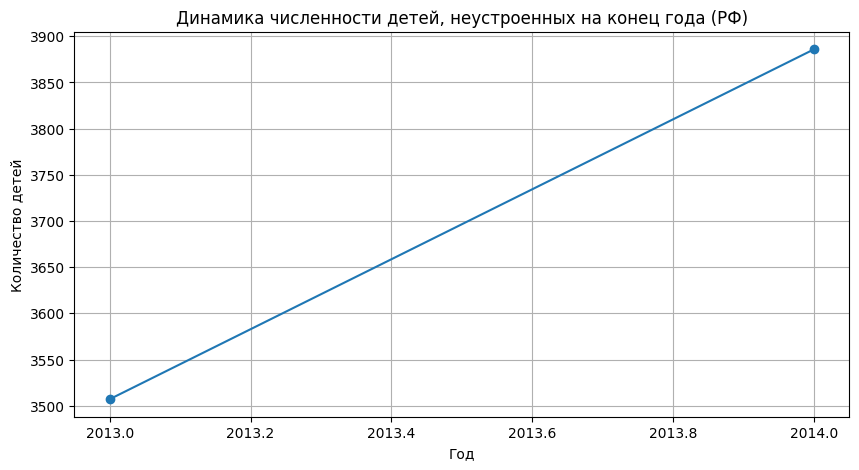

In [ ]:
plt.figure(figsize=(10, 5))
"""Горизонт - год, вертикаль - число сирот"""
plt.plot(russia_by_year_need_fam['year'], russia_by_year_need_fam['indicator_value'], marker='o', linestyle='-')
plt.title('Динамика численности детей, неустроенных на конец года (РФ)')
plt.xlabel('Год')
plt.ylabel('Количество детей')
plt.grid(True)
plt.show()

<u>DONE</u>:
> - [x] 2.Дети, нуждающиеся в устройстве в семьи (динамика по годам)
___

# Приток детей за год

In [ ]:

mask = (df['indicator_category'] == '1. Учет и устройство детей, оставшихся без попечения родителей') & \
        (df['dimension'] == 'всего') & (df['indicator'] == 'детей, выявленных и учтенных за отчетный год')

df_total_3 = df[mask]

influx_per_year = df_total_3.groupby('year')['indicator_value'].sum().reset_index()

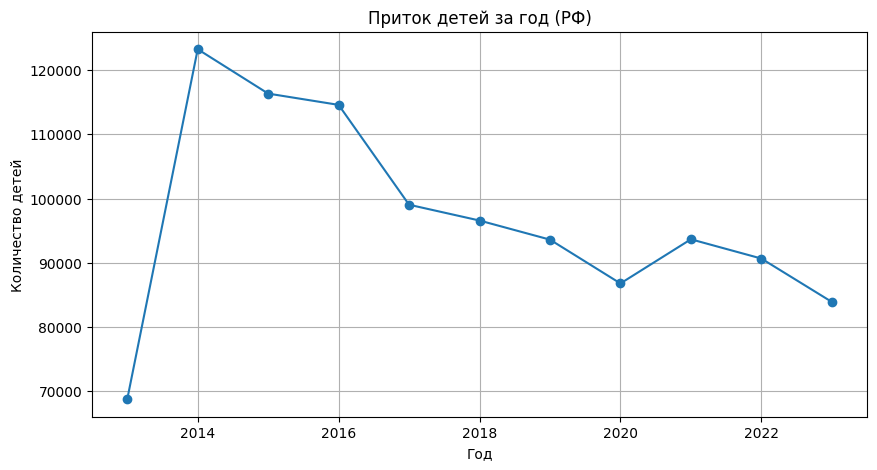

In [ ]:
plt.figure(figsize=(10, 5))
"""Горизонт - год, вертикаль - число сирот"""
plt.plot(influx_per_year['year'], influx_per_year['indicator_value'], marker='o', linestyle='-')
plt.title('Приток детей за год (РФ)')
plt.xlabel('Год')
plt.ylabel('Количество детей')
plt.grid(True)
plt.show()

<u>DONE</u>:
> - [x] 3.Приток детей за год (Выявлены и учтены на конец отчетного года)
___

# Численность детей, родители которых лишены или ограничены в родительских правах

In [14]:
pd.set_option('display.max_rows', None)      # все строки
pd.set_option('display.max_colwidth', None)  # полная ширина колонок

In [15]:

mask = ((df['indicator_category'] == '5. Зашита прав детей') & (df['dimension'] == 'всего') & \
        ((df['main_level'] == 'численность детей, родители которых лишены родительских прав') | \
        (df['main_level'] == 'численность детей, родители которых ограничены в родительских правах')))

df_total_4 = df[mask]

by_parents_limited_rights = df_total_4.groupby('year')['indicator_value'].sum().reset_index()

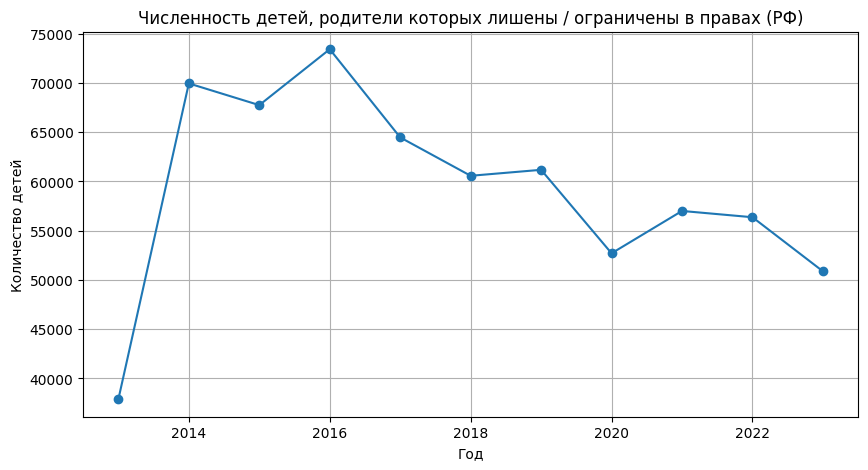

In [16]:
plt.figure(figsize=(10, 5))
"""Горизонт - год, вертикаль - число сирот"""
plt.plot(by_parents_limited_rights['year'], by_parents_limited_rights['indicator_value'], marker='o', linestyle='-')
plt.title('Численность детей, родители которых лишены / ограничены в правах (РФ)')
plt.xlabel('Год')
plt.ylabel('Количество детей')
plt.grid(True)
plt.show()

Если нужно сравнивать отдельно лишены ЛИБО ограничены - 2 динамики отдельно:

year  main_level                                                          indicator_value
2014  численность детей, родители которых лишены родительских прав              12345
2014  численность детей, родители которых ограничены в родительских правах       6789
2015  ...

Группировка сначала по году, а потом отдельно по main_level

In [17]:
mask_children = (df['indicator_category'] == '5. Зашита прав детей') & \
                (df['dimension'] == 'всего') & \
                ((df['main_level'] == 'численность детей, родители которых лишены родительских прав') | \
                 (df['main_level'] == 'численность детей, родители которых ограничены в родительских правах'))

df_total_4 = df[mask_children].copy()
by_children = df_total_4.groupby(['year', 'main_level'])['indicator_value'].sum().reset_index()

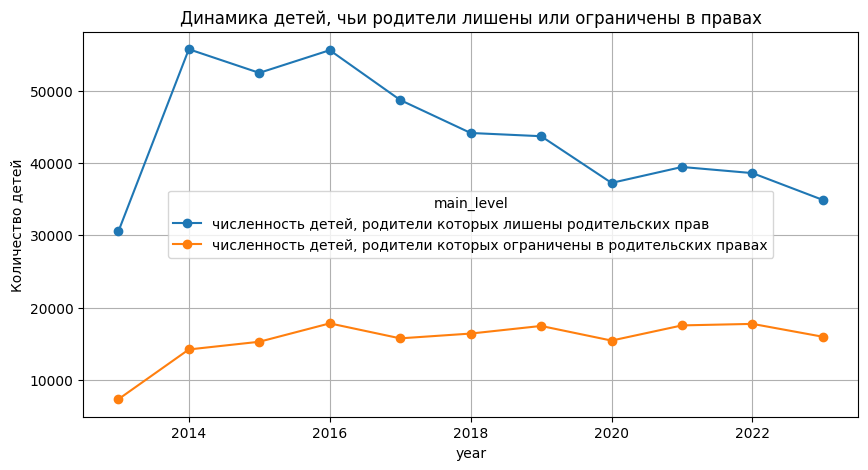

In [ ]:
# Создаём сводную таблицу: строки — год, столбцы — main_level, значения — сумма
pivot = df_total_4.pivot_table(index='year', columns='main_level', values='indicator_value', aggfunc='sum')
pivot.plot(marker='o', figsize=(10,5))
plt.title('Динамика детей, чьи родители лишены или ограничены в правах')
plt.ylabel('Количество детей')
plt.grid(True)
plt.show()